# Station-MAE — Pipeline Exploration

Step-by-step walkthrough of the full stack:
data loading → spatial/temporal embeddings → encoder → decoder → mini-training → evaluation.

**Set `DATA_ROOT` (and optionally `PATH_SWISSSHAPE`) in the Config cell before running.**

In [1]:
import sys, math, os
sys.path.insert(0, "..")

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from torch.utils.data import DataLoader, Subset
import pytorch_lightning as pl
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning.callbacks import (
    ModelCheckpoint, EarlyStopping, LearningRateMonitor,
)

# ── User config ────────────────────────────────────────────────────────────
DATA_ROOT       = "/Users/aureliedejong/Documents/ETH/_DAS Project/PeakWeatherDataset" #/home/renku/work
PATH_SWISSSHAPE = "/Users/aureliedejong/Documents/ETH/_DAS Project/swissboundaries3d_2026-01_2056_5728.shp.zip"

# Window / forecast
WINDOW_SIZE      = 12    # 2 h of input context    (12 × 10 min)
MAX_DELTA_STEPS  = 6     # max lead-time: 1 h       ( 6 × 10 min)
NUM_DELTA        = 3     # K lead-times sampled per sample (multi-delta)
DELTA_STEPS      = MAX_DELTA_STEPS   # kept for legacy use in single-delta cells

# Subset mode — set to True to train on 2 years only (pipeline sanity check).
SUBSET_MODE  = True
SUBSET_YEARS = [2020, 2021]

# Model
BATCH_SIZE   = 8
D_MODEL      = 128

# Mini-training
MINI_SAVE_DIR = "./checkpoints_mini"   # checkpoints + Lightning logs written here

print("Imports OK")

# Device priority: CUDA (cloud GPU) > MPS (Apple Silicon) > CPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() and torch.backends.mps.is_built() else
    "cpu"
)
print(f"Device: {device}  |  Lightning {pl.__version__}")

if device.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True
    torch.backends.cuda.enable_flash_sdp(True)
    print("  CUDA optimisations enabled (TF32, Flash Attention)")

if SUBSET_MODE:
    print(f"[Subset mode]  Training years: {SUBSET_YEARS}")

Imports OK
Device: mps  |  Lightning 2.6.1
[Subset mode]  Training years: [2020, 2021]


## Step 1 — Load PeakWeather dataset

In [2]:
from data.dataset import (
    load_peakweather, build_spatial_features, build_observations,
    normalise_observations, compute_obs_stats, StationMAEDataset,
    VARIABLE_NAMES, NUM_VARIABLES, TRAIN_YEARS,
)

ds = load_peakweather(DATA_ROOT)
print(ds)
print(f"\nStations  : {ds.num_stations}")
print(f"Timesteps : {ds.num_time_steps}")
print(f"Parameters:")
ds.show_parameters_description()

PeakWeatherDataset(num_time_steps=461952, num_stations=156, num_parameters=8)

Stations  : 156
Timesteps : 461952
Parameters:
          name param_short                                                                    Description
      humidity    ure200s0               Relative air humidity 2 m above ground; current value (per cent)
 precipitation    rre150z0                                  Precipitation; ten minutes total (millimeter)
      pressure    prestas0 Atmospheric pressure at barometric altitude (QFE); current value (hectopascal)
   temperature    tre200s0               Air temperature 2 m above ground; current value (degree Celsius)
wind_direction    dkl010z0                                      Wind direction; ten minutes mean (degree)
    wind_speed    fkl010z0                      Wind speed scalar; ten minutes mean in m/s (meter/second)
        wind_u  fkl010z0_u                                  u component (E-W) of the wind. (meter/second)
        wind_v  fkl010z0_v

In [3]:
print("Number of spatial variables: ", len(ds.stations_table.columns), "\n", list(ds.stations_table.columns))

Number of spatial variables:  20 
 ['station_name', 'latitude', 'longitude', 'station_height', 'swiss_easting', 'swiss_northing', 'ASPECT_2000M_SIGRATIO1', 'WE_DERIVATIVE_2000M_SIGRATIO1', 'TPI_2000M', 'SN_DERIVATIVE_10000M_SIGRATIO1', 'dem', 'SN_DERIVATIVE_2000M_SIGRATIO1', 'SLOPE_10000M_SIGRATIO1', 'ASPECT_10000M_SIGRATIO1', 'SLOPE_2000M_SIGRATIO1', 'STD_2000M', 'STD_10000M', 'TPI_10000M', 'WE_DERIVATIVE_10000M_SIGRATIO1', 'station_type']


In [4]:
ds.stations_table.head()


,station_name,latitude,longitude,station_height,swiss_easting,swiss_northing,ASPECT_2000M_SIGRATIO1,WE_DERIVATIVE_2000M_SIGRATIO1,TPI_2000M,SN_DERIVATIVE_10000M_SIGRATIO1,dem,SN_DERIVATIVE_2000M_SIGRATIO1,SLOPE_10000M_SIGRATIO1,ASPECT_10000M_SIGRATIO1,SLOPE_2000M_SIGRATIO1,STD_2000M,STD_10000M,TPI_10000M,WE_DERIVATIVE_10000M_SIGRATIO1,station_type
nat_abbr,,,,,,,,,,,,,,,,,,,,
ABO,Adelboden,46.491703,7.560703,1321.38,2.609372e+06,1.148939e+06,124.863129,-0.167379,-53.303345,-0.026807,1317.771851,0.116605,1.702339,25.582031,11.529667,120.940262,374.830623,-443.723877,-0.012833,meteo_station
AEG,Oberägeri,47.133636,8.608206,724.43,2.688729e+06,1.220956e+06,190.899567,0.010865,-20.030273,-0.013760,724.173462,0.056423,1.099379,315.811829,3.288559,27.269887,141.396220,-165.792114,0.013376,meteo_station
AIG,Aigle,46.326647,6.924472,381.02,2.560403e+06,1.130714e+06,301.137115,0.002014,-0.256348,0.006587,381.100006,-0.001216,0.760270,119.760574,0.134786,0.000000,287.689425,-195.166718,-0.011520,meteo_station
ALT,Altdorf,46.887069,8.621894,437.86,2.690181e+06,1.193563e+06,240.803589,0.020179,-2.120819,-0.009294,438.587494,0.011276,0.995863,57.677086,1.324231,0.000000,493.449619,-518.464722,-0.014689,meteo_station
AND,Andeer,46.610139,9.431981,987.10,2.752692e+06,1.164037e+06,285.070679,0.079193,-57.052063,-0.033264,984.354675,-0.021324,2.702750,314.800964,4.688558,71.570846,459.982181,-745.938782,0.033496,meteo_station


## Step 2 — Visualise stations on DEM

from data.visualize import plot_stations_on_dem, markers_from_stations_table

all_markers = markers_from_stations_table(
    ds.stations_table,
    default_color="steelblue",
    size=20,
    label="Meteo stations",
)

plot_stations_on_dem(
    ds,
    stations=all_markers,
    path_swissshape=PATH_SWISSSHAPE,
    title="PeakWeather — All Meteo Stations",
)
plt.show()


## Step 3 — Spatial features  `(N, 15)`

In [5]:
spatial, spatial_stats = build_spatial_features(ds)
N = spatial.shape[0]

print(f"spatial shape : {tuple(spatial.shape)}")
print(f"mean  (≈ 0)   : {spatial.mean(0).abs().max():.6f}")
print(f"std   (≈ 1)   : {spatial.std(0).mean():.6f}")
print()
print("Feature layout (15 dims):")
layout = [
    "swiss_easting", "swiss_northing",
    "sin(aspect 2km)", "cos(aspect 2km)", "sin(aspect 10km)", "cos(aspect 10km)",
    "station_height", "dem", "TPI_2000m",
    "slope_2km", "slope_10km", "SN_deriv_2km", "SN_deriv_10km",
    "WE_deriv_2km", "WE_deriv_10km",
]
for i, name in enumerate(layout[:spatial.shape[1]]):
    print(f"  [{i:2d}] {name}")

spatial shape : (156, 15)
mean  (≈ 0)   : 0.000002
std   (≈ 1)   : 1.000000

Feature layout (15 dims):
  [ 0] swiss_easting
  [ 1] swiss_northing
  [ 2] sin(aspect 2km)
  [ 3] cos(aspect 2km)
  [ 4] sin(aspect 10km)
  [ 5] cos(aspect 10km)
  [ 6] station_height
  [ 7] dem
  [ 8] TPI_2000m
  [ 9] slope_2km
  [10] slope_10km
  [11] SN_deriv_2km
  [12] SN_deriv_10km
  [13] WE_deriv_2km
  [14] WE_deriv_10km


In [6]:
spatial_stats

{'mean': tensor([ 2.6621e+06,  1.1825e+06, -5.6574e-02, -1.7042e-01, -6.8261e-02,
          5.1764e-02,  1.0522e+03,  1.0495e+03,  2.8322e+00,  5.0896e+00,
          2.5845e+00,  2.4399e-02, -4.6782e-04,  9.5552e-03,  4.8143e-03]),
 'std': tensor([7.8817e+04, 5.0829e+04, 6.6287e-01, 7.3117e-01, 6.7992e-01, 7.3265e-01,
         7.6075e+02, 7.5644e+02, 1.0911e+02, 5.0903e+00, 2.0809e+00, 8.6525e-02,
         4.2030e-02, 9.1694e-02, 4.0033e-02])}

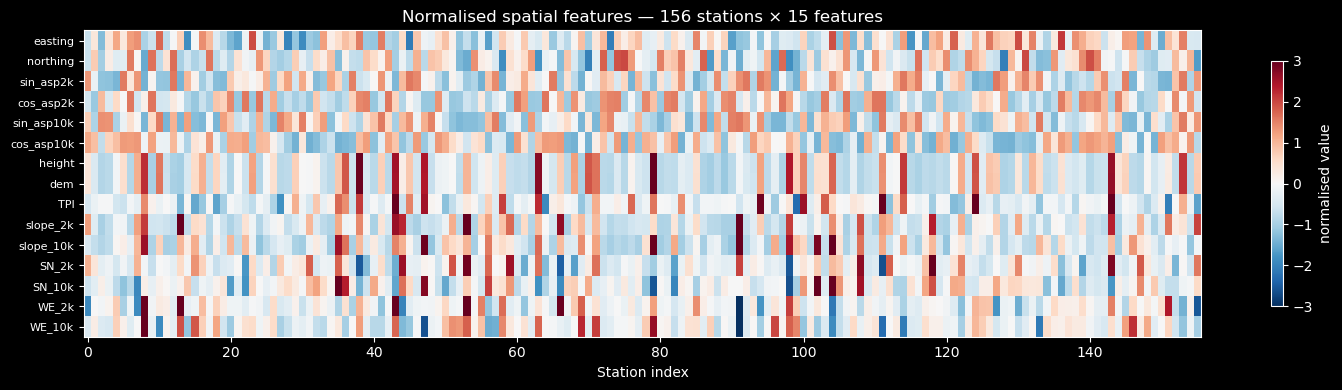

spatial tensor: (156, 15)  dtype=torch.float32


In [7]:
labels_15 = [
    "easting","northing",
    "sin_asp2k","cos_asp2k","sin_asp10k","cos_asp10k",
    "height","dem","TPI",
    "slope_2k","slope_10k","SN_2k","SN_10k","WE_2k","WE_10k",
]

fig, ax = plt.subplots(figsize=(15, 4))
im = ax.imshow(spatial.T.numpy(), aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3)
ax.set_yticks(range(spatial.shape[1]))
ax.set_yticklabels(labels_15, fontsize=8)
ax.set_xlabel("Station index")
ax.set_title(f"Normalised spatial features — {spatial.shape[0]} stations × 15 features")
plt.colorbar(im, ax=ax, shrink=0.8, label="normalised value")
plt.tight_layout()
plt.show()
print(f"spatial tensor: {tuple(spatial.shape)}  dtype={spatial.dtype}")

## Step 4 — Temporal encoding (Fourier)

`encode_temporal(ts)` → **hours since 1970-01-01 UTC** (a single float).
`TemporalEmbedding` then expands this scalar into log-spaced Fourier features
spanning λ_min = 10 min → λ_max = 1 year, capturing diurnal, weekly, monthly and seasonal cycles.

In [8]:
from model.embeddings import encode_temporal, TemporalEmbedding, TEMPORAL_FOURIER_DIM

# Single timestamp example
ts_ex = pd.Timestamp("2021-06-21 12:00:00+00:00")
h_ex  = encode_temporal(ts_ex)
print(f"encode_temporal('{ts_ex}')  =  {h_ex:.2f} h since epoch")
print(f"  ≈ {h_ex / 8766:.2f} years since 1970-01-01")

# Fourier module configuration
n_wl       = TEMPORAL_FOURIER_DIM // 2
lambda_min = 1.0 / 6.0
lambda_max = 365.25 * 24.0
lambdas    = torch.exp(torch.linspace(math.log(lambda_min), math.log(lambda_max), n_wl))
print(f"\nFourier dim    : {TEMPORAL_FOURIER_DIM}  ({n_wl} wavelengths)")
print(f"λ_min          : {lambda_min:.4f} h  ({lambda_min*60:.0f} min)")
print(f"λ_max          : {lambda_max:.1f} h  ({lambda_max/24:.1f} days ≈ 1 year)")
print(f"λ values (h)   : {[f'{l:.1f}' for l in lambdas.tolist()]}")

encode_temporal('2021-06-21 12:00:00+00:00')  =  451188.00 h since epoch
  ≈ 51.47 years since 1970-01-01

Fourier dim    : 32  (16 wavelengths)
λ_min          : 0.1667 h  (10 min)
λ_max          : 8766.0 h  (365.2 days ≈ 1 year)
λ values (h)   : ['0.2', '0.3', '0.7', '1.5', '3.0', '6.2', '12.9', '26.6', '54.9', '113.3', '234.0', '482.9', '996.8', '2057.5', '4246.9', '8766.0']


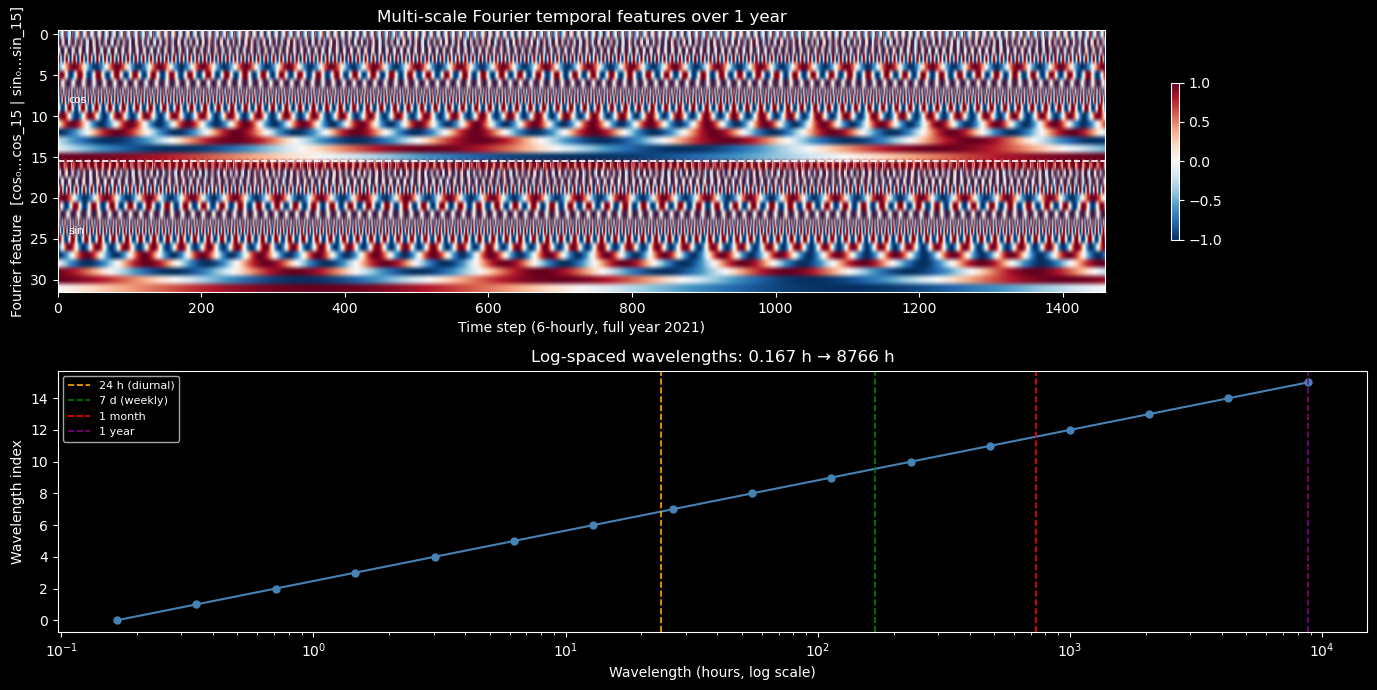

In [9]:
# Visualise Fourier features over a full year sampled every 6 hours
start   = pd.Timestamp("2021-01-01 00:00:00+00:00")
n_steps = 365 * 4                                          # 4 samples/day × 365 days
times   = [start + pd.Timedelta(hours=6*i) for i in range(n_steps)]
h_arr   = torch.tensor([encode_temporal(ts) for ts in times])  # (n_steps,)

temp_mod = TemporalEmbedding(d_model=D_MODEL, fourier_dim=TEMPORAL_FOURIER_DIM)
with torch.no_grad():
    fourier = temp_mod._fourier(h_arr)    # (n_steps, TEMPORAL_FOURIER_DIM)

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Top — Fourier feature matrix over time
ax = axes[0]
im = ax.imshow(fourier.numpy().T, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xlabel("Time step (6-hourly, full year 2021)")
ax.set_ylabel(f"Fourier feature  [cos₀…cos_{n_wl-1} | sin₀…sin_{n_wl-1}]")
ax.axhline(n_wl - 0.5, color="white", linewidth=1.2, linestyle="--")
ax.text(n_steps * 0.01, n_wl * 0.5, "cos", color="white", fontsize=8, va="center")
ax.text(n_steps * 0.01, n_wl + n_wl * 0.5, "sin", color="white", fontsize=8, va="center")
ax.set_title("Multi-scale Fourier temporal features over 1 year")
plt.colorbar(im, ax=ax, shrink=0.6)

# Bottom — log-spaced wavelengths with reference lines
ax2 = axes[1]
ax2.semilogx(lambdas.numpy(), range(n_wl), "o-", markersize=5, color="steelblue")
for lam, label, color in [
    (24,        "24 h (diurnal)",  "orange"),
    (24*7,      "7 d (weekly)",    "green"),
    (24*30.5,   "1 month",         "red"),
    (24*365.25, "1 year",          "purple"),
]:
    ax2.axvline(lam, color=color, linestyle="--", linewidth=1.2, label=label)
ax2.set_xlabel("Wavelength (hours, log scale)")
ax2.set_ylabel("Wavelength index")
ax2.set_title(f"Log-spaced wavelengths: {lambda_min:.3f} h → {lambda_max:.0f} h")
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()


## Step 5 — Full observation tensor  `(T, N, V)`

In [10]:
obs_full, mask_full, timestamps_full = build_observations(ds)
T, N, V = obs_full.shape

print(f"obs  shape  : {tuple(obs_full.shape)}   (T, N, V)")
print(f"mask shape  : {tuple(mask_full.shape)}")
print(f"Time range  : {timestamps_full[0]}  →  {timestamps_full[-1]}")
print(f"Resolution  : 10 min")
print()

# Per-variable availability
print(f"{'Variable':<16}  {'% present':>10}  {'bar'}")
print("-" * 50)
for v, name in enumerate(VARIABLE_NAMES):
    pct = 100.0 * mask_full[:, :, v].float().mean().item()
    bar = "█" * int(pct / 5)
    print(f"  {name:<14}  {pct:>9.1f}%  {bar}")


obs  shape  : (461952, 156, 6)   (T, N, V)
mask shape  : (461952, 156, 6)
Time range  : 2017-01-01 00:00:00+00:00  →  2025-10-13 23:50:00+00:00
Resolution  : 10 min

Variable           % present  bar
--------------------------------------------------
  temperature          95.3%  ███████████████████
  pressure             88.5%  █████████████████
  humidity             95.2%  ███████████████████
  wind_u               96.0%  ███████████████████
  wind_v               96.0%  ███████████████████
  precipitation        88.4%  █████████████████


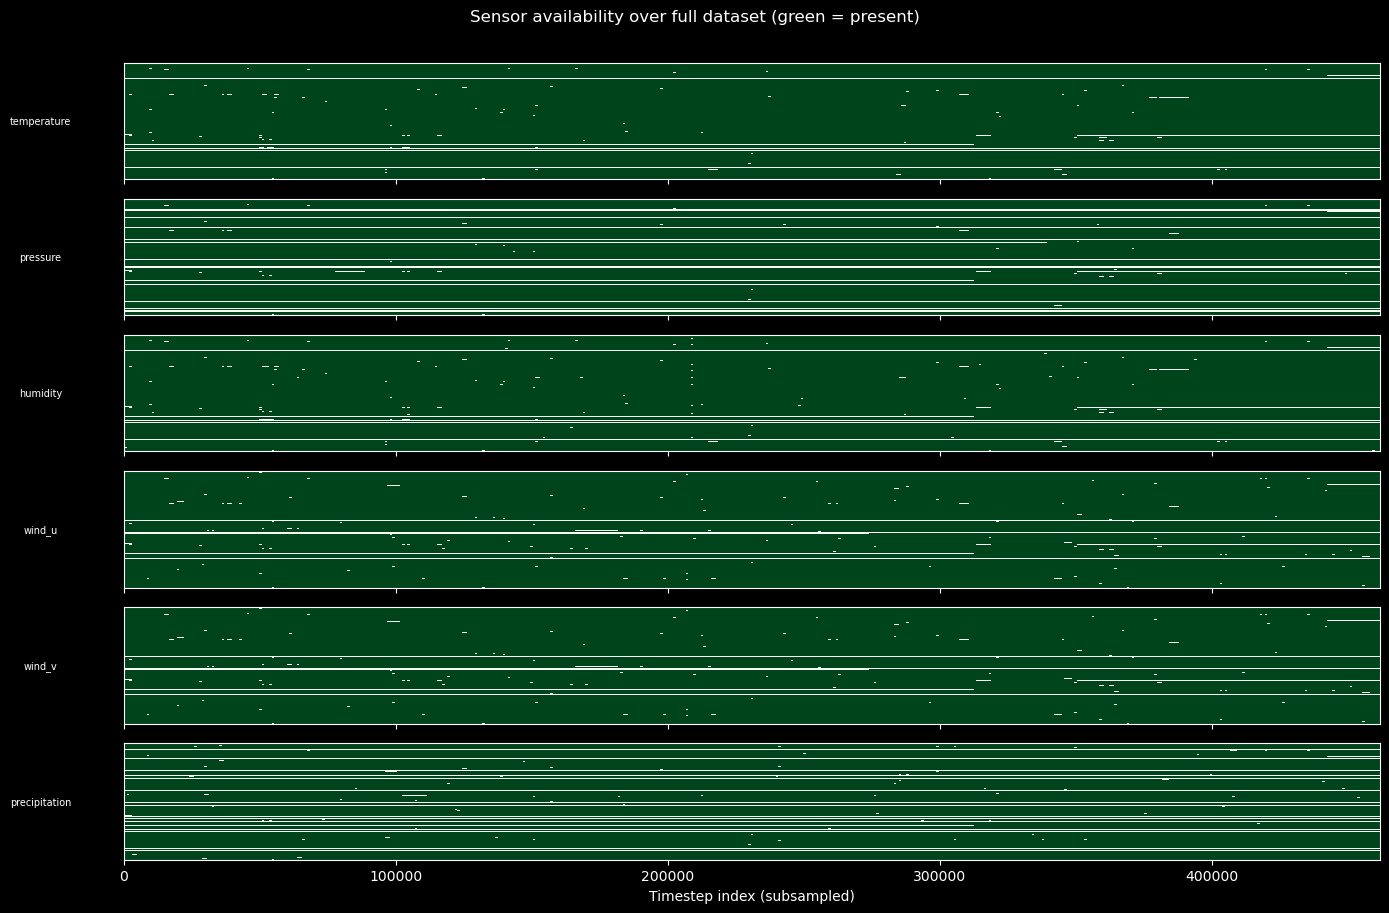

In [11]:
# Per-variable availability heatmap across time (subsampled)
stride = max(1, T // 500)

fig, axes = plt.subplots(V, 1, figsize=(14, V * 1.5), sharex=True)
for v, name in enumerate(VARIABLE_NAMES):
    ax  = axes[v]
    mat = mask_full[::stride, :, v].numpy()    # (T', N)
    ax.imshow(mat.T, aspect="auto", cmap="Greens", vmin=0, vmax=1,
              interpolation="none", extent=[0, T, N, 0])
    ax.set_ylabel(name, fontsize=7, rotation=0, labelpad=60, va="center")
    ax.set_yticks([])

axes[-1].set_xlabel("Timestep index (subsampled)")
fig.suptitle("Sensor availability over full dataset (green = present)", y=1.01)
plt.tight_layout(); plt.show()


## Step 6 — Normalisation (train split stats)

In [12]:
# Compute normalisation statistics from the TRAINING split only (2017–2021).
# These are then passed to all three splits so val and test use the same scale.
obs_stats = compute_obs_stats(ds)

print(f"{'Variable':<16}  {'mean':>10}  {'std':>10}  {'unit (raw)'}")
print("-" * 60)
units = ["°C", "hPa", "%", "m/s", "m/s", "mm"]
for v, name in enumerate(VARIABLE_NAMES):
    m = obs_stats["mean"][v].item()
    s = obs_stats["std"][v].item()
    print(f"  {name:<14}  {m:>10.4f}  {s:>10.4f}  {units[v]}")

print()
print("After normalisation: mean ≈ 0,  std ≈ 1 for each variable (training-split statistics).")

Variable                mean         std  unit (raw)
------------------------------------------------------------
  temperature         7.6234      8.7950  °C
  pressure          898.2521     82.1194  hPa
  humidity           74.7900     20.3312  %
  wind_u              0.3506      2.6272  m/s
  wind_v              0.0597      2.5150  m/s
  precipitation       0.0223      0.1529  mm

After normalisation: mean ≈ 0,  std ≈ 1 for each variable (training-split statistics).


## Step 7 — StationMAEDataset

In [13]:
# obs_stats was computed from the training split above — pass to all splits so
# val/test are normalised with the same scale.
#
# Parameters:
#   cache_dir            — folder for the pre-built tensor cache (avoids slow raw reads)
#   num_delta_per_sample — K lead-times sampled per sample (>1 → multi-delta batches)
#   max_delta_steps      — worst-case horizon used for valid-index check
#   train_years          — restrict training-split to specific years (None = full 2017–2021)

_train_years = SUBSET_YEARS if SUBSET_MODE else None

train_ds = StationMAEDataset(
    ds, window_size=WINDOW_SIZE, delta_steps=MAX_DELTA_STEPS, split="train",
    obs_stats=obs_stats,
    num_delta_per_sample=NUM_DELTA,
    max_delta_steps=MAX_DELTA_STEPS,
    cache_dir=DATA_ROOT,
    train_years=_train_years,
)
val_ds = StationMAEDataset(
    ds, window_size=WINDOW_SIZE, delta_steps=MAX_DELTA_STEPS, split="val",
    obs_stats=train_ds.obs_stats,       # always normalise with training-split stats
    num_delta_per_sample=1,             # single-delta for consistent evaluation
    max_delta_steps=MAX_DELTA_STEPS,
    cache_dir=DATA_ROOT,
    train_years=_train_years,           # keeps stats consistent if stats recomputed
)
test_ds = StationMAEDataset(
    ds, window_size=WINDOW_SIZE, delta_steps=MAX_DELTA_STEPS, split="test",
    obs_stats=train_ds.obs_stats,
    num_delta_per_sample=1,
    max_delta_steps=MAX_DELTA_STEPS,
    cache_dir=DATA_ROOT,
    train_years=_train_years,
)

print(f"Subset mode   : {SUBSET_MODE}  (train years: {_train_years or 'all 2017–2021'})")
print(f"Train samples : {len(train_ds):,}  (K={NUM_DELTA} lead-times per sample)")
print(f"Val   samples : {len(val_ds):,}  (K=1)")
print(f"Test  samples : {len(test_ds):,}  (K=1)")
print(f"Window size W : {train_ds.window_size} steps = {train_ds.window_size * 10 / 60:.1f} h")
print(f"Max delta     : {MAX_DELTA_STEPS} steps = {MAX_DELTA_STEPS * 10 / 60:.1f} h lead-time")

[Cache] Loading from /Users/aureliedejong/Documents/ETH/_DAS Project/PeakWeatherDataset/peakweather_obs_cache.pt …
[Cache] Loaded in 0.8s  (obs (461952, 156, 6))
[Cache] Loading from /Users/aureliedejong/Documents/ETH/_DAS Project/PeakWeatherDataset/peakweather_obs_cache.pt …
[Cache] Loaded in 0.6s  (obs (461952, 156, 6))
[Cache] Loading from /Users/aureliedejong/Documents/ETH/_DAS Project/PeakWeatherDataset/peakweather_obs_cache.pt …
[Cache] Loaded in 0.6s  (obs (461952, 156, 6))
Subset mode   : True  (train years: [2020, 2021])
Train samples : 105,230  (K=3 lead-times per sample)
Val   samples : 52,543  (K=1)
Test  samples : 105,230  (K=1)
Window size W : 12 steps = 2.0 h
Max delta     : 6 steps = 1.0 h lead-time


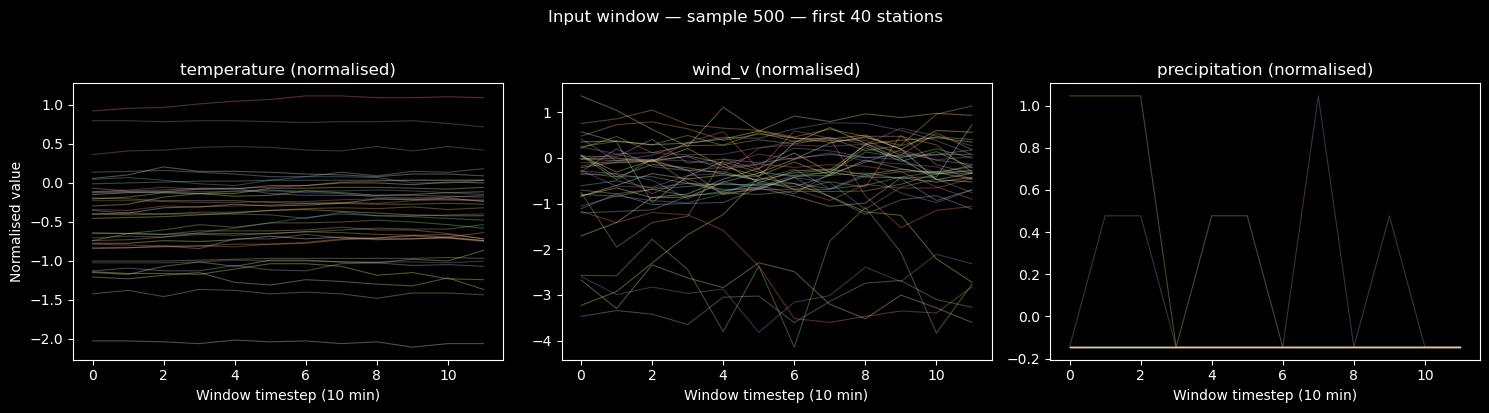

In [14]:
# Plot input window for one sample — temperature across stations
sample  = train_ds[500]
x       = sample["x"]       # (W, N, V)
x_mask  = sample["x_mask"]  # (W, N, V)
W, N, V = x.shape

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for col, (var_idx, title) in enumerate([(0, "temperature"), (4, "wind_v"), (5, "precipitation")]):
    ax = axes[col]
    for n in range(min(N, 40)):
        present = x_mask[:, n, var_idx].bool()
        vals    = x[:, n, var_idx].clone().numpy().astype(float)
        vals[~present.numpy()] = float("nan")
        ax.plot(vals, alpha=0.35, linewidth=0.8)
    ax.set_title(f"{title} (normalised)")
    ax.set_xlabel("Window timestep (10 min)")
    if col == 0:
        ax.set_ylabel("Normalised value")

plt.suptitle(f"Input window — sample 500 — first 40 stations", y=1.02)
plt.tight_layout(); plt.show()

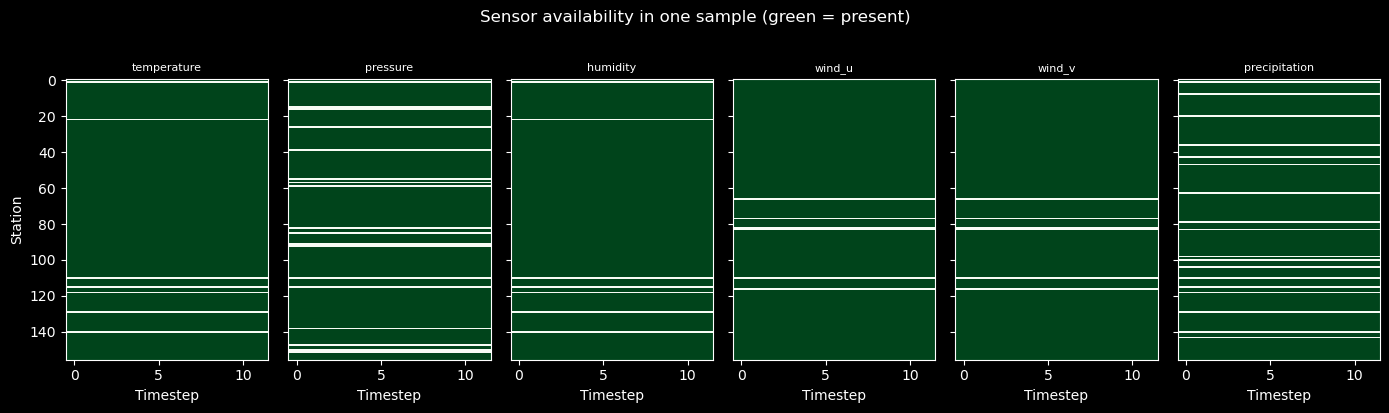

In [15]:
# Missing data heatmap across the input window for the same sample
fig, axes = plt.subplots(1, V, figsize=(14, 4), sharey=True)
for v_idx, var in enumerate(VARIABLE_NAMES):
    ax  = axes[v_idx]
    mat = x_mask[:, :, v_idx].numpy()   # (W, N)
    ax.imshow(mat.T, aspect="auto", cmap="Greens", vmin=0, vmax=1,
              interpolation="none")
    ax.set_title(var, fontsize=8)
    ax.set_xlabel("Timestep")
    if v_idx == 0:
        ax.set_ylabel("Station")

fig.suptitle("Sensor availability in one sample (green = present)", y=1.02)
plt.tight_layout(); plt.show()


## Step 8 — Embeddings

Three embeddings are summed per token:
- **Variable** `VariableProjection` — *what* was measured
- **Spatial** `SpatialEmbedding` — *where* the station is (static topo, 15-dim)
- **Temporal** `TemporalEmbedding` — *when* (Aurora Fourier, shared across stations)

The decoder adds a fourth: **Delta** `DeltaTimeEmbedding` — forecast lead-time (Fourier-based).

In [16]:
from model.embeddings import (
    PositionalEmbedding, StationEmbedding,
    TemporalEmbedding, VariableProjection, DeltaTimeEmbedding,
    TEMPORAL_FOURIER_DIM, DELTA_FOURIER_DIM,
    POSITION_FOURIER_DIM, STATION_CHAR_DIM,
    TARGET_VARIABLE_NAMES, NUM_TARGET_VARIABLES,
)

pos_emb     = PositionalEmbedding(d_model=D_MODEL, fourier_dim=POSITION_FOURIER_DIM)
station_emb = StationEmbedding(d_model=D_MODEL, input_dim=STATION_CHAR_DIM)
temporal_emb = TemporalEmbedding(d_model=D_MODEL, fourier_dim=TEMPORAL_FOURIER_DIM)
var_proj     = VariableProjection(num_vars=NUM_VARIABLES, d_model=D_MODEL)
delta_emb    = DeltaTimeEmbedding(d_model=D_MODEL, fourier_dim=DELTA_FOURIER_DIM)

sp_in   = spatial.unsqueeze(0)              # (1, N, 15) — add batch dimension
x_in    = sample["x"].unsqueeze(0)          # (1, W, N, V)
xm_in   = sample["x_mask"].unsqueeze(0)     # (1, W, N, V)
hrs_in  = sample["x_hours"].unsqueeze(0)    # (1, W)

with torch.no_grad():
    vp_out  = var_proj(x_in.view(1 * W, N, V),
                       xm_in.view(1 * W, N, V)).view(1, W, N, D_MODEL)
    p1_out  = pos_emb(sp_in[..., :2])        # (1, N, d_model) — easting/northing
    p2_out  = station_emb(sp_in[..., 2:])    # (1, N, d_model) — characteristics
    tp_out  = temporal_emb(hrs_in)           # (1, W, d_model)

print(f"v  VariableProjection  : {tuple(vp_out.shape)}   (B, W, N, d_model)")
print(f"p1 PositionalEmbedding : {tuple(p1_out.shape)}      (B, N, d_model)  — easting/northing Fourier")
print(f"p2 StationEmbedding    : {tuple(p2_out.shape)}      (B, N, d_model)  — 13-dim characteristics MLP")
print(f"t  TemporalEmbedding   : {tuple(tp_out.shape)}      (B, W, d_model)")
print()
print("Token = v + p1 + p2 + t  (four independent components summed)")

v  VariableProjection  : (1, 12, 156, 128)   (B, W, N, d_model)
p1 PositionalEmbedding : (1, 156, 128)      (B, N, d_model)  — easting/northing Fourier
p2 StationEmbedding    : (1, 156, 128)      (B, N, d_model)  — 13-dim characteristics MLP
t  TemporalEmbedding   : (1, 12, 128)      (B, W, d_model)

Token = v + p1 + p2 + t  (four independent components summed)


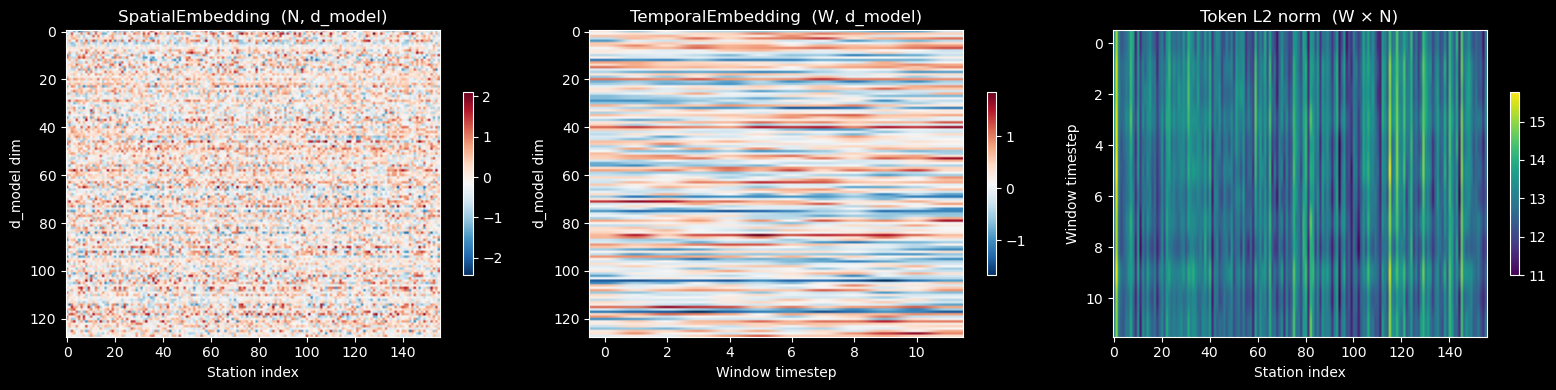

In [17]:
# Assemble the full token: sum of four embedding components
# mirrors encoder._build_tokens(): v + p1 + p2 + t → (B, W, N, d_model)
with torch.no_grad():
    token = (
        vp_out                        # (B, W, N, d_model) — variable projection
        + p1_out.unsqueeze(1)         # (B, 1, N, d_model) — positional (easting/northing)
        + p2_out.unsqueeze(1)         # (B, 1, N, d_model) — station characteristics
        + tp_out.unsqueeze(2)         # (B, W, 1, d_model) — temporal
    )  # (B, W, N, d_model)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Spatial embedding heatmap (all stations)
ax = axes[0]
im = ax.imshow(p2_out[0].detach().numpy().T, aspect="auto", cmap="RdBu_r")
ax.set_xlabel("Station index"); ax.set_ylabel("d_model dim")
ax.set_title("SpatialEmbedding  (N, d_model)")
plt.colorbar(im, ax=ax, shrink=0.6)

# Temporal embedding heatmap (all window steps)
ax = axes[1]
im = ax.imshow(tp_out[0].detach().numpy().T, aspect="auto", cmap="RdBu_r")
ax.set_xlabel("Window timestep"); ax.set_ylabel("d_model dim")
ax.set_title("TemporalEmbedding  (W, d_model)")
plt.colorbar(im, ax=ax, shrink=0.6)

# Combined token norm per (station, window-step)
ax = axes[2]
tok_norm = token[0].norm(dim=-1).detach().numpy()  # (W, N)
im = ax.imshow(tok_norm, aspect="auto", cmap="viridis")
ax.set_xlabel("Station index"); ax.set_ylabel("Window timestep")
ax.set_title("Token L2 norm  (W × N)")
plt.colorbar(im, ax=ax, shrink=0.6)

plt.tight_layout(); plt.show()


## Step 9 — Encoder forward pass

In [ ]:
from model.encoder import StationMAEEncoder

encoder = StationMAEEncoder(
    d_model=D_MODEL, num_heads=4, num_layers=4,
    dropout=0.0, mask_ratio=0.5,
)
print(f"Encoder parameters: {sum(p.numel() for p in encoder.parameters()):,}")

encoder.eval()
with torch.no_grad():
    encoded, masked_idx, visible_idx = encoder(
        x=x_in, x_mask=xm_in, spatial=sp_in, x_hours=hrs_in,
    )

B        = x_in.shape[0]
N_vis    = visible_idx.shape[1]
N_masked = masked_idx.shape[1]
print(f"\nInput tokens        : {B} × {W} × {N} = {B*W*N} total")
print(f"Visible stations    : {N_vis} / {N}  (mask_ratio=0.50)")
print(f"Masked  stations    : {N_masked} / {N}")
print(f"Encoded shape       : {tuple(encoded.shape)}   (B, W*N_vis, d_model)")
print(f"Visible station idx : {visible_idx[0].tolist()}")
print(f"Masked  station idx : {masked_idx[0].tolist()}")


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Encoder output heatmap
ax = axes[0]
im = ax.imshow(encoded[0].detach().numpy().T, aspect="auto", cmap="RdBu_r")
ax.set_xlabel(f"Token index  (W={W} × N_vis={N_vis})")
ax.set_ylabel("d_model dimension")
ax.set_title("Encoder output — visible tokens only")
for w in range(1, W):
    ax.axvline(w * N_vis, color="white", linewidth=0.5, alpha=0.6)
plt.colorbar(im, ax=ax, shrink=0.6)

# Token norms
ax2 = axes[1]
norms = encoded[0].norm(dim=-1).detach().numpy()   # (W*N_vis,)
ax2.plot(norms)
ax2.set_xlabel("Token index")
ax2.set_ylabel("L2 norm")
ax2.set_title("Encoder token norms")
for w in range(1, W):
    ax2.axvline(w * N_vis, color="gray", linewidth=0.5, linestyle="--")

plt.tight_layout(); plt.show()


In [ ]:
# DataLoader batch test
loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
batch  = next(iter(loader))

print("DataLoader batch shapes:")
for k, v in batch.items():
    print(f"  {k:<16} {tuple(v.shape) if isinstance(v, torch.Tensor) else v}")

# Run batch through encoder
encoder.eval()
with torch.no_grad():
    enc_out, m_idx, v_idx = encoder(
        x=batch["x"],
        x_mask=batch["x_mask"],
        spatial=batch["spatial"][0],   # (N, 15) — same across batch
        x_hours=batch["x_hours"],
    )
print(f"\nEncoder output (batch): {tuple(enc_out.shape)}")

## Step 10 — Decoder forward pass

In [ ]:
from model.decoder import StationMAEDecoder

decoder = StationMAEDecoder(
    d_model=D_MODEL, num_heads=4, num_layers=2, dropout=0.0,
)
print(f"Decoder parameters: {sum(p.numel() for p in decoder.parameters()):,}")

# Re-use encoder output from previous cell.
#
# decoder.forward() now handles both calling conventions automatically:
#
#   Single-delta  y_hours/delta_steps: (B,)   → returns (B, N, num_target_vars)
#   Multi-delta   y_hours/delta_steps: (B, K) → returns (B, K, N, num_target_vars)
#                 all K lead-times processed in ONE transformer pass via N×K queries
#
# Demonstrate both:
spatial_N15 = batch["spatial"][0]   # (N, 15)

decoder.eval()
with torch.no_grad():
    # ── Single-delta (slice first lead-time) ──────────────────────────────
    preds_1 = decoder(
        encoded_vis=enc_out,
        spatial=spatial_N15,
        y_hours=batch["y_hours"][:, 0],       # (B,)
        delta_steps=batch["delta_steps"][:, 0],  # (B,)
    )
    print(f"Single-delta preds : {tuple(preds_1.shape)}   (B, N, num_target_vars)")

    # ── Multi-delta (all K lead-times at once) ────────────────────────────
    preds_K = decoder(
        encoded_vis=enc_out,
        spatial=spatial_N15,
        y_hours=batch["y_hours"],             # (B, K)
        delta_steps=batch["delta_steps"],     # (B, K)
    )
    print(f"Multi-delta  preds : {tuple(preds_K.shape)}   (B, K, N, num_target_vars)")
    print(f"  K={preds_K.shape[1]} lead-times processed in one decoder pass ✓")

In [ ]:
# Prediction vs target for the first sample in the batch
fig, axes = plt.subplots(1, NUM_TARGET_VARIABLES, figsize=(16, 3))
pred_0   = preds[0].detach().numpy()          # (N, NUM_TARGET_VARIABLES)
target_0 = batch["y"][0].numpy()              # (N, V)
mask_0   = batch["y_mask"][0].bool().numpy()  # (N, V)

for v, name in enumerate(TARGET_VARIABLE_NAMES):
    ax = axes[v]
    m  = mask_0[:, v]
    ax.scatter(target_0[m, v], pred_0[m, v], alpha=0.5, s=10, color="steelblue")
    lim = max(abs(target_0[m, v]).max(), abs(pred_0[m, v]).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], "k--", linewidth=0.8, alpha=0.6)
    ax.set_title(name, fontsize=8)
    ax.set_xlabel("target"); ax.set_ylabel("pred") if v == 0 else None

plt.suptitle("Decoder predictions vs. targets (random-init model — expect scatter)", y=1.03)
plt.tight_layout(); plt.show()

## Step 11 — Full StationMAE forward pass

In [ ]:
from model.mae import StationMAE

# Note: max_delta_steps is NOT a StationMAE constructor argument.
# DeltaTimeEmbedding uses continuous Fourier encoding over hours,
# so no upper-bound on lead-time is baked into the architecture.
mae = StationMAE(
    d_model=D_MODEL, enc_heads=4, enc_layers=4,
    dec_heads=4, dec_layers=2, mlp_ratio=4.0,
    dropout=0.0, mask_ratio=0.5,
)
print(f"Total parameters  : {mae.count_parameters():,}")
enc_p = sum(p.numel() for p in mae.encoder.parameters() if p.requires_grad)
dec_p = sum(p.numel() for p in mae.decoder.parameters() if p.requires_grad)
print(f"  Encoder         : {enc_p:,}")
print(f"  Decoder         : {dec_p:,}")

# ── Single-delta forward (K=1, val batch) ─────────────────────────────────
val_batch_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
val_batch = next(iter(val_batch_loader))

mae.eval()
with torch.no_grad():
    loss_s, preds_s, masked_idx_s = mae(
        x=val_batch["x"],
        x_mask=val_batch["x_mask"],
        spatial=val_batch["spatial"][0],
        x_hours=val_batch["x_hours"],
        y=val_batch["y"],
        y_mask=val_batch["y_mask"],
        y_hours=val_batch["y_hours"],    # (B,)  — val_ds has num_delta=1
        delta_steps=val_batch["delta_steps"],
    )
print(f"\n[Single-delta forward]")
print(f"  Loss (normalised MSE on masked stations) : {loss_s.item():.5f}")
print(f"  Preds shape  : {tuple(preds_s.shape)}   (B, N, num_target_vars)")
print(f"  Masked idx   : {tuple(masked_idx_s.shape)}   (B, N_masked)")

# ── Multi-delta forward (K=NUM_DELTA, train batch) ────────────────────────
# Encoder runs once; decoder also runs ONCE via N×K query tokens.
# All K lead-times are processed in a single transformer pass.
train_batch_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
train_batch = next(iter(train_batch_loader))

with torch.no_grad():
    loss_m, preds_m, masked_idx_m = mae.forward_multi_delta(
        x=train_batch["x"],
        x_mask=train_batch["x_mask"],
        spatial=train_batch["spatial"][0],
        x_hours=train_batch["x_hours"],
        y=train_batch["y"],                     # (B, K, N, V)
        y_mask=train_batch["y_mask"],
        y_hours=train_batch["y_hours"],         # (B, K)
        delta_steps=train_batch["delta_steps"], # (B, K)
    )
K_actual = train_batch["delta_steps"].shape[1]
print(f"\n[Multi-delta forward  K={NUM_DELTA}]")
print(f"  Loss (mean over K, normalised MSE) : {loss_m.item():.5f}")
print(f"  Preds shape  : {tuple(preds_m.shape)}   (B, K, N, num_target_vars)")
print(f"  Delta steps sampled : {train_batch['delta_steps'][0].tolist()}  (first sample)")
print(f"  Encoder ran once, decoder ran once (N×K={train_batch['spatial'][0].shape[0]}×{K_actual} queries) ✓")

## Step 12 — Mini-training with PyTorch Lightning (sanity check)

Trains a **tiny model** (d=64, 2+1 layers) on a small random subset using
`StationMAELightning` + `pl.Trainer` — the same path as a real `main.py` run.

This exercises:
- **Multi-delta batches** (`num_delta_per_sample=NUM_DELTA=3`)
- **Early stopping** via `pl.callbacks.EarlyStopping`
- **Checkpoint saving** via `ModelCheckpoint` — `best.ckpt`, `last.ckpt`, periodic `epoch_NNN.ckpt`
- **Lightning CSV logger** — `metrics.csv` written to `MINI_SAVE_DIR/logs/version_0/`

Expected: loss decreases, no NaNs, all files appear in `MINI_SAVE_DIR`.

In [ ]:
from model.mae import StationMAE
from model.lightning_module import StationMAELightning

# ── Tiny model ────────────────────────────────────────────────────────────
MINI_D       = 64
MINI_EPOCHS  = 10   # early stopping will likely trigger before this
MINI_SUBSET  = 256  # training samples
MINI_VAL_SUB = 64   # validation samples

mini_model = StationMAE(
    d_model=MINI_D, enc_heads=4, enc_layers=2,
    dec_heads=4, dec_layers=1, mlp_ratio=2.0,
    dropout=0.1, mask_ratio=0.5,
)
print(f"Mini-model parameters: {mini_model.count_parameters():,}")

# ── Subset DataLoaders ────────────────────────────────────────────────────
n_sub          = min(MINI_SUBSET, len(train_ds))
perm           = torch.randperm(len(train_ds))[:n_sub].tolist()
mini_train_sub = Subset(train_ds, perm)

n_val          = min(MINI_VAL_SUB, len(val_ds))
mini_val_sub   = Subset(val_ds, list(range(n_val)))

mini_train_loader = DataLoader(mini_train_sub, batch_size=8, shuffle=True,
                               num_workers=0, drop_last=True)
mini_val_loader   = DataLoader(mini_val_sub,   batch_size=8, shuffle=False,
                               num_workers=0)

print(f"Train subset : {len(mini_train_sub)} samples  "
      f"({len(mini_train_loader)} batches/epoch, K={NUM_DELTA})")
print(f"Val   subset : {len(mini_val_sub)} samples  "
      f"({len(mini_val_loader)} batches/epoch, K=1)")

# ── Training config ───────────────────────────────────────────────────────
mini_cfg = {
    "lr":            1e-3,
    "weight_decay":  0.05,
    "epochs":        MINI_EPOCHS,
    "warmup_epochs": 1,
    "grad_clip":     1.0,
    "patience":      3,
    "min_delta":     1e-4,
    "save_every":    2,
}

# ── Lightning module ──────────────────────────────────────────────────────
mini_lit = StationMAELightning(model=mini_model, cfg=mini_cfg)

# ── Logger (CSV only — no WandB needed for notebook exploration) ──────────
os.makedirs(MINI_SAVE_DIR, exist_ok=True)
mini_logger = CSVLogger(save_dir=MINI_SAVE_DIR, name="logs", version=0)

# ── Callbacks ─────────────────────────────────────────────────────────────
mini_callbacks = [
    ModelCheckpoint(
        dirpath=MINI_SAVE_DIR,
        filename="best",
        monitor="val/loss",
        mode="min",
        save_top_k=1,
        save_last=True,     # also writes last.ckpt after each epoch
        verbose=True,
    ),
    ModelCheckpoint(
        dirpath=MINI_SAVE_DIR,
        filename="epoch_{epoch:03d}",
        every_n_epochs=mini_cfg["save_every"],
        save_top_k=-1,
    ),
    EarlyStopping(
        monitor="val/loss",
        patience=mini_cfg["patience"],
        min_delta=mini_cfg["min_delta"],
        mode="min",
        verbose=True,
    ),
    LearningRateMonitor(logging_interval="step"),
]

print(f"\nCheckpoints → {os.path.abspath(MINI_SAVE_DIR)}")
print(f"CSV logs    → {os.path.abspath(os.path.join(MINI_SAVE_DIR, 'logs', 'version_0'))}")

In [ ]:
# pl.Trainer handles: device placement, AMP, gradient clipping,
# LR scheduling, early stopping, checkpointing, and CSV logging.

mini_trainer = pl.Trainer(
    max_epochs=mini_cfg["epochs"],
    accelerator="auto",          # auto-selects CUDA → MPS → CPU
    devices="auto",
    precision="32-true",         # fp32; set "16-mixed" for CUDA/MPS in real runs
    gradient_clip_val=mini_cfg["grad_clip"],
    callbacks=mini_callbacks,
    logger=mini_logger,
    log_every_n_steps=1,         # log every step (small dataset — avoids empty epochs)
    enable_progress_bar=True,
)

mini_trainer.fit(
    model=mini_lit,
    train_dataloaders=mini_train_loader,
    val_dataloaders=mini_val_loader,
)
print("\nMini-training complete ✓")

## Step 12b — Inspect saved checkpoints and Lightning CSV log

In [ ]:
# ── Checkpoint files ─────────────────────────────────────────────────────
print(f"Checkpoint files in {MINI_SAVE_DIR}/")
for fn in sorted(os.listdir(MINI_SAVE_DIR)):
    fp = os.path.join(MINI_SAVE_DIR, fn)
    if os.path.isfile(fp):
        size_kb = os.path.getsize(fp) / 1024
        print(f"  {fn:<30}  {size_kb:6.1f} KB")

# ── Lightning CSV log ─────────────────────────────────────────────────────
log_path = os.path.join(MINI_SAVE_DIR, "logs", "version_0", "metrics.csv")
logs_raw = pd.read_csv(log_path)
print(f"\nColumns in metrics.csv: {list(logs_raw.columns)}")

# Epoch-level summary: keep only rows where epoch metric is logged
# Lightning logs per-step (train) and per-epoch (val + train epoch mean)
epoch_logs = (
    logs_raw
    .dropna(subset=["val/loss"])          # epoch-end rows have val/loss
    [["epoch", "train/loss_epoch", "val/loss", "val/overall_rmse"]]
    .rename(columns={
        "train/loss_epoch": "train_loss",
        "val/loss":         "val_loss",
        "val/overall_rmse": "val_rmse",
    })
    .reset_index(drop=True)
)
print(f"\nEpoch-level summary ({len(epoch_logs)} epochs logged):")
display(epoch_logs.round(5))

# ── Loss curves ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

ax = axes[0]
ax.plot(epoch_logs["epoch"], epoch_logs["train_loss"], "o-",
        color="steelblue", label="train")
ax.plot(epoch_logs["epoch"], epoch_logs["val_loss"],   "s--",
        color="tomato",    label="val")
best_ep = epoch_logs.loc[epoch_logs["val_loss"].idxmin(), "epoch"]
ax.axvline(best_ep, color="green", lw=1.2, ls=":", label=f"best (ep {int(best_ep)})")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss (norm. MSE)")
ax.set_title("Train / Val Loss"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(epoch_logs["epoch"], epoch_logs["val_rmse"], "D-", color="darkorange")
ax.set_xlabel("Epoch"); ax.set_ylabel("Val overall RMSE")
ax.set_title("Validation RMSE"); ax.grid(alpha=0.3)

# Step-level train loss (all steps)
step_logs = logs_raw.dropna(subset=["train/loss_step"])[["step", "train/loss_step"]]
ax = axes[2]
ax.plot(step_logs["step"], step_logs["train/loss_step"],
        linewidth=0.8, color="slategray", alpha=0.8)
ax.set_xlabel("Step"); ax.set_ylabel("Train loss (per step)")
ax.set_title("Train loss — step level"); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_val = epoch_logs["val_loss"].min()
print(f"\nBest val/loss = {best_val:.5f}  at epoch {int(best_ep)}")

## Step 13 — Quick evaluation on val subset

In [ ]:
from engine.evaluate import evaluate, print_metrics

# Load best checkpoint — Lightning saves as best.ckpt with "model." prefix in state_dict
best_ckpt_path = os.path.join(MINI_SAVE_DIR, "best.ckpt")
if os.path.exists(best_ckpt_path):
    ckpt = torch.load(best_ckpt_path, map_location=device, weights_only=False)
    # Strip the "model." prefix added by LightningModule
    sd = {k[len("model."):]: v
          for k, v in ckpt["state_dict"].items()
          if k.startswith("model.")}
    mini_model.load_state_dict(sd)
    print(f"Loaded best.ckpt  (epoch {ckpt.get('epoch', '?')})")
else:
    print(f"best.ckpt not found at {best_ckpt_path} — evaluating current weights")

# evaluate() expects a val_loader with K=1 (single-delta) batches
N_VAL_SUB  = min(128, len(val_ds))
val_sub    = Subset(val_ds, list(range(N_VAL_SUB)))
val_loader = DataLoader(val_sub, batch_size=8, shuffle=False, num_workers=0)

metrics = evaluate(mini_model.to(device), val_loader, device)
print_metrics(metrics)
print("(metrics in normalised space)")

In [ ]:
# Scatter: predicted vs. true for all target variables on val subset
# val_loader uses K=1 → forward() returns preds (B, N, num_target_vars)
mini_model.eval()
all_preds, all_targets, all_masks = [], [], []

with torch.no_grad():
    for b in val_loader:
        sp = b["spatial"][0].to(device)
        _, preds_v, m_idx_v = mini_model(
            b["x"].to(device), b["x_mask"].to(device), sp,
            b["x_hours"].to(device),
            b["y"].to(device), b["y_mask"].to(device),
            b["y_hours"].to(device), b["delta_steps"].to(device),
        )
        B_v = preds_v.shape[0]
        for bi in range(B_v):
            mi = m_idx_v[bi].cpu()          # move indices to CPU before indexing CPU tensors
            all_preds.append(preds_v[bi, mi].cpu())
            all_targets.append(b["y"][bi, mi])         # (n_masked, V)
            all_masks.append(b["y_mask"][bi, mi])       # (n_masked, V)

P  = torch.cat(all_preds)       # (total_masked, num_target_vars)
T_ = torch.cat(all_targets)     # (total_masked, num_vars including precip)
M  = torch.cat(all_masks).bool()

fig, axes = plt.subplots(1, NUM_TARGET_VARIABLES, figsize=(16, 3))
for v, name in enumerate(TARGET_VARIABLE_NAMES):
    ax = axes[v]
    mv = M[:, v]
    pv = P[mv, v].numpy()
    tv = T_[mv, v].numpy()
    ax.scatter(tv, pv, alpha=0.3, s=6, rasterized=True, color="steelblue")
    lim = max(abs(tv).max(), abs(pv).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.8, alpha=0.6)
    rmse = float(((pv - tv) ** 2).mean() ** 0.5)
    ax.set_title(f"{name}\nRMSE={rmse:.3f}", fontsize=8)
    ax.set_xlabel("target")
    if v == 0:
        ax.set_ylabel("pred")

plt.suptitle(
    f"Val predictions vs. targets — masked stations  "
    f"(best.pt, W={WINDOW_SIZE}×10min, Δ=1–{MAX_DELTA_STEPS}×10min)",
    y=1.03, fontsize=9,
)
plt.tight_layout()
plt.show()

---
## All steps passed ✓

The full stack — data loading → spatial/temporal embeddings → encoder → decoder → loss → backward — runs correctly.

Next: launch a full training run with `python main.py --data_root <path>`